In [15]:
import numpy as np
import pandas as pd
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_columns = 20
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

In [16]:
names1880 = pd.read_csv('data/babynames/yob1880.txt',names=['name','sex','births'])
names1880
names1880.groupby('sex').births.sum()

sex
F     90993
M    110493
Name: births, dtype: int64

In [9]:
pieces = []
for year in range(1880, 2011):
    path = f"data/babynames/yob{year}.txt"
    frame = pd.read_csv(path, names=['name','sex','births'])

    frame['year'] = year
    pieces.append(frame)

names = pd.concat(pieces, ignore_index = True)
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


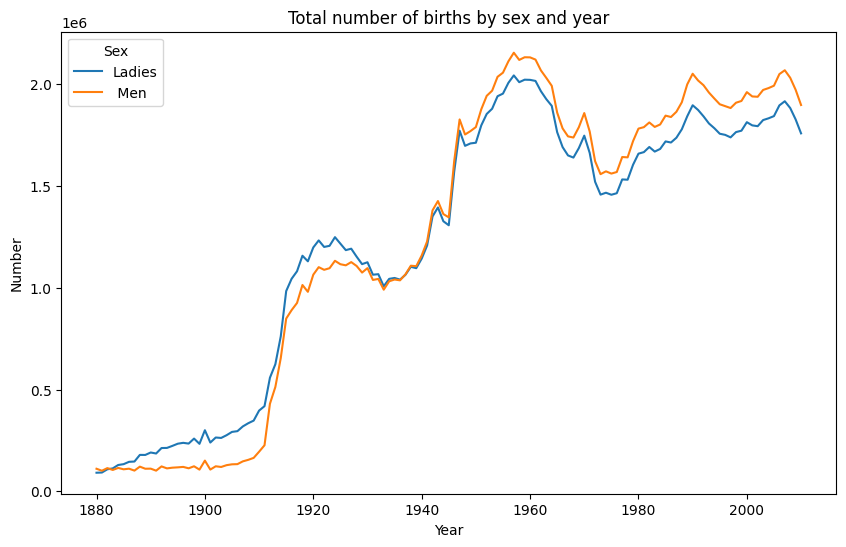

In [10]:
total_births = names.pivot_table('births', index='year',columns='sex',aggfunc=sum)
total_births.tail()
gfg = total_births.plot(title='Total number of births by sex and year')
gfg.set(xlabel = 'Year', ylabel = 'Number')
plt.legend(title='Sex', labels=['Ladies', ' Men'])

In [11]:
def add_prop(group):
    group['prop'] = group['births'] / group['births'].sum()
    return group
names = names.groupby(['year','sex']).apply(add_prop)
names
names.groupby(['year','sex'])['prop'].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

In [20]:
def get_top1000(group):
    return group.sort_values('births', ascending=False)[:1000]
grouped = names.groupby(['year','sex'])
top1000 = grouped.apply(get_top1000)
top1000.head()
top1000 = top1000.reset_index(drop=True)
top1000.head()


,name,births,prop
0,Mary,7065,0.077643
1,Anna,2604,0.028618
2,Emma,2003,0.022013
3,Elizabeth,1939,0.021309
4,Minnie,1746,0.019188


In [21]:
boys = top1000[top1000['sex']=='M']
girls = top1000[top1000['sex']=='F']

KeyError: 'sex'